<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Named-Entity-Recognition-NER-System/blob/main/Named_Entity_Recognition_(NER)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/ner_dataset.csv',skip_blank_lines=True,skipinitialspace=True, encoding='latin1')
df.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [44]:
df['Tag'].unique()

array(['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim',
       'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve',
       'I-eve', 'I-nat'], dtype=object)

In [4]:
df.shape

(1048575, 4)

In [5]:
df.isnull().sum()

,0
Sentence #,1000616
Word,10
POS,0
Tag,0


In [6]:
df.duplicated().sum()

np.int64(953668)

In [7]:
df.dtypes

,0
Sentence #,object
Word,object
POS,object
Tag,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Sentence #  47959 non-null    object
 1   Word        1048565 non-null  object
 2   POS         1048575 non-null  object
 3   Tag         1048575 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [9]:
from itertools import chain

In [10]:
def get_dict_map(data, word_or_tag):
    token2id = {}
    id2token = {}

    if word_or_tag == 'word':
        vocab = list(set(data['Word'].to_list()))
    else:
        vocab = list(set(data['Tag'].to_list()))

    id2token = {id: tok for id, tok in enumerate(vocab)}
    token2id = {tok: id for id, tok in enumerate(vocab)}

    return token2id, id2token


# Usage
word2id, id2word = get_dict_map(df, 'word')
tag2id, id2tag = get_dict_map(df, 'tag')

In [11]:
tag2id

{'B-art': 0,
 'B-geo': 1,
 'I-eve': 2,
 'B-org': 3,
 'O': 4,
 'I-org': 5,
 'B-eve': 6,
 'I-nat': 7,
 'I-per': 8,
 'B-tim': 9,
 'B-gpe': 10,
 'I-tim': 11,
 'I-art': 12,
 'B-per': 13,
 'I-gpe': 14,
 'B-nat': 15,
 'I-geo': 16}

In [12]:
word2id

{'mid-1999': 0,
 'linkup': 1,
 'Saffir-Simpson': 2,
 'EEC': 3,
 'warship': 4,
 '2-million': 5,
 'sense': 6,
 'cost-control': 7,
 'dollars': 8,
 'forbidden': 9,
 'Azerbaijan': 10,
 'Kolkata': 11,
 'risks': 12,
 'hacked': 13,
 'Andrei': 14,
 'Riga': 15,
 'Wemple': 16,
 'attacks': 17,
 'numbers': 18,
 'Salvation': 19,
 'transmissible': 20,
 'Thaksin': 21,
 'decision': 22,
 'duty-free': 23,
 'pensions': 24,
 'Uddin': 25,
 '400': 26,
 'Observer': 27,
 'geographical': 28,
 'Bild': 29,
 'years': 30,
 '20th': 31,
 'breach': 32,
 'attache': 33,
 'misfortune': 34,
 'beautiful': 35,
 'Professor': 36,
 'spills': 37,
 'jockey': 38,
 'Printemps': 39,
 'Sabrina': 40,
 'Passaro': 41,
 'techniques': 42,
 'Wardak': 43,
 'Ovidio': 44,
 'Selim': 45,
 'Cook': 46,
 '40.3': 47,
 'hereditary': 48,
 'comments': 49,
 'obesity': 50,
 'humiliating': 51,
 'housing': 52,
 'transferred': 53,
 'who': 54,
 'vaunting': 55,
 'Us': 56,
 'concentrate': 57,
 'Capt.': 58,
 'Nepal-United': 59,
 'Cody': 60,
 'Townsend': 61,
 

In [13]:
df['word_id']=(df['Word']).map(word2id)
df['tag_id']=(df['Tag']).map(tag2id)
df.head()

,Sentence #,Word,POS,Tag,word_id,tag_id
0,Sentence: 1,Thousands,NNS,O,23607,4
1,NaN,of,IN,O,26635,4
2,NaN,demonstrators,NNS,O,7811,4
3,NaN,have,VBP,O,18526,4
4,NaN,marched,VBN,O,26820,4


In [14]:
# fill nan
df_fillnan=df.ffill(axis=0)
df_fillnan.head()

,Sentence #,Word,POS,Tag,word_id,tag_id
0,Sentence: 1,Thousands,NNS,O,23607,4
1,Sentence: 1,of,IN,O,26635,4
2,Sentence: 1,demonstrators,NNS,O,7811,4
3,Sentence: 1,have,VBP,O,18526,4
4,Sentence: 1,marched,VBN,O,26820,4


In [15]:
final_df=df_fillnan.groupby(
['Sentence #'],
as_index=False)[['Word','POS','Tag','word_id','tag_id']].agg(lambda x: list(x))
final_df.head()

,Sentence #,Word,POS,Tag,word_id,tag_id
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[NNS, IN, NNS, VBP, VBN, IN, NNP, TO, VB, DT, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo...","[23607, 26635, 7811, 18526, 26820, 458, 25984,...","[4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 1, 4, 4, ..."
1,Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[JJ, NNS, VBP, PRP, VBP, TO, VB, NN, TO, JJ, J...","[B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,...","[3944, 20755, 4026, 2193, 14629, 4971, 20151, ...","[10, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,..."
2,Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[NN, NNS, NNP, VBD, JJ, NNS, IN, DT, NNP, JJ, ...","[O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O...","[25255, 30690, 13946, 20347, 4375, 2224, 18542...","[4, 4, 9, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 3, ..."
3,Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[PRP, VBD, IN, DT, NN, JJ, NN, IN, NN, NNS, .]","[O, O, O, O, O, O, O, O, O, O, O]","[210, 14825, 15345, 27599, 2696, 2659, 9403, 4...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]"
4,Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[NNP, NN, NN, NNP, NNP, VBD, NNP, ,, NNP, ,, J...","[B-geo, O, O, B-per, I-per, O, B-tim, O, B-geo...","[21604, 28912, 15675, 23506, 31724, 5163, 3215...","[1, 4, 4, 13, 8, 4, 9, 4, 1, 4, 10, 4, 10, 4, ..."


In [16]:
# padding the shorter sentence to make input size of same size
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# check word and tags from final data
print("Statement \n",final_df['Word'])
print("\n")
print("Tag \n",final_df['Tag'])


# Getting max size of statement
statement_list=final_df['word_id'].tolist()
max_len_statement=max([len(statement) for statement in statement_list])
print("Max statement length: ",max_len_statement)

# Getting max size of statement
tag_list=final_df['tag_id'].tolist()
max_len_tag=max([len(tag) for tag in tag_list])
print("Max Tag length: ",max_len_tag)

pad_statement=pad_sequences(statement_list,maxlen=max_len_statement,padding='post',value=word2id['The'])
pad_tags=pad_sequences(tag_list,maxlen=max_len_tag,padding='post',value=tag2id['O'])
print("Statement AFTER PADDING: ",pad_statement)
print("Tag AFTER PADDING: ",pad_tags)

Statement 
 0        [Thousands, of, demonstrators, have, marched, ...
1        [Iranian, officials, say, they, expect, to, ge...
2        [Helicopter, gunships, Saturday, pounded, mili...
3        [They, left, after, a, tense, hour-long, stand...
4        [U.N., relief, coordinator, Jan, Egeland, said...
                               ...                        
47954    [Opposition, leader, Mir, Hossein, Mousavi, ha...
47955    [On, Thursday, ,, Iranian, state, media, publi...
47956    [Following, Iran, 's, disputed, June, 12, elec...
47957    [Since, then, ,, authorities, have, held, publ...
47958    [The, United, Nations, is, praising, the, use,...
Name: Word, Length: 47959, dtype: object


Tag 
 0        [O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo...
1        [B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,...
2        [O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O...
3                        [O, O, O, O, O, O, O, O, O, O, O]
4        [B-geo, O, O, B-per, I-per, O, B-tim, O, B-ge

In [17]:
#Converting output tags to One Hot Encoding
from tensorflow.keras.utils import to_categorical
pad_tags=to_categorical(pad_tags)

print(pad_tags)
print("Shape of tag: ",pad_tags.shape)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Shape of t

In [18]:
# split the dataset in traiing and testing
from sklearn.model_selection import train_test_split
train_statement,test_statement,train_tag,test_tag=train_test_split(pad_statement,pad_tags,test_size=0.1,random_state=42)
print("Shape of train statement: ",train_statement.shape)
print("Shape of test statement: ",test_statement.shape)
print("Shape of train tag: ",train_tag.shape)
print("Shape of test tag: ",test_tag.shape)

Shape of train statement:  (43163, 104)
Shape of test statement:  (4796, 104)
Shape of train tag:  (43163, 104, 17)
Shape of test tag:  (4796, 104, 17)


In [19]:
# Import All models
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
shape=train_statement[1].shape
input_dim=len(word2id)
output_dim=64
input_length=max_len_statement
output_units=len(tag2id)

In [21]:
import tensorflow
input_layer=Input(shape=(104,))

embeding=Embedding(input_dim=input_dim,output_dim=output_dim)(input_layer)
lstm1=LSTM(units=output_dim,return_sequences=True,activation='relu')(embeding)
lstm2=LSTM(units=output_dim,return_sequences=True,activation='relu')(lstm1)

output=TimeDistributed(Dense(units=output_units,activation='softmax'))(lstm2)

model=tensorflow.keras.Model(input_layer,output)
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])


In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 104, 64)        │     2,251,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 104, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 104, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 104, 17)        │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,318,545 (8.84 MB)

 Trainable params: 2,318,545 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

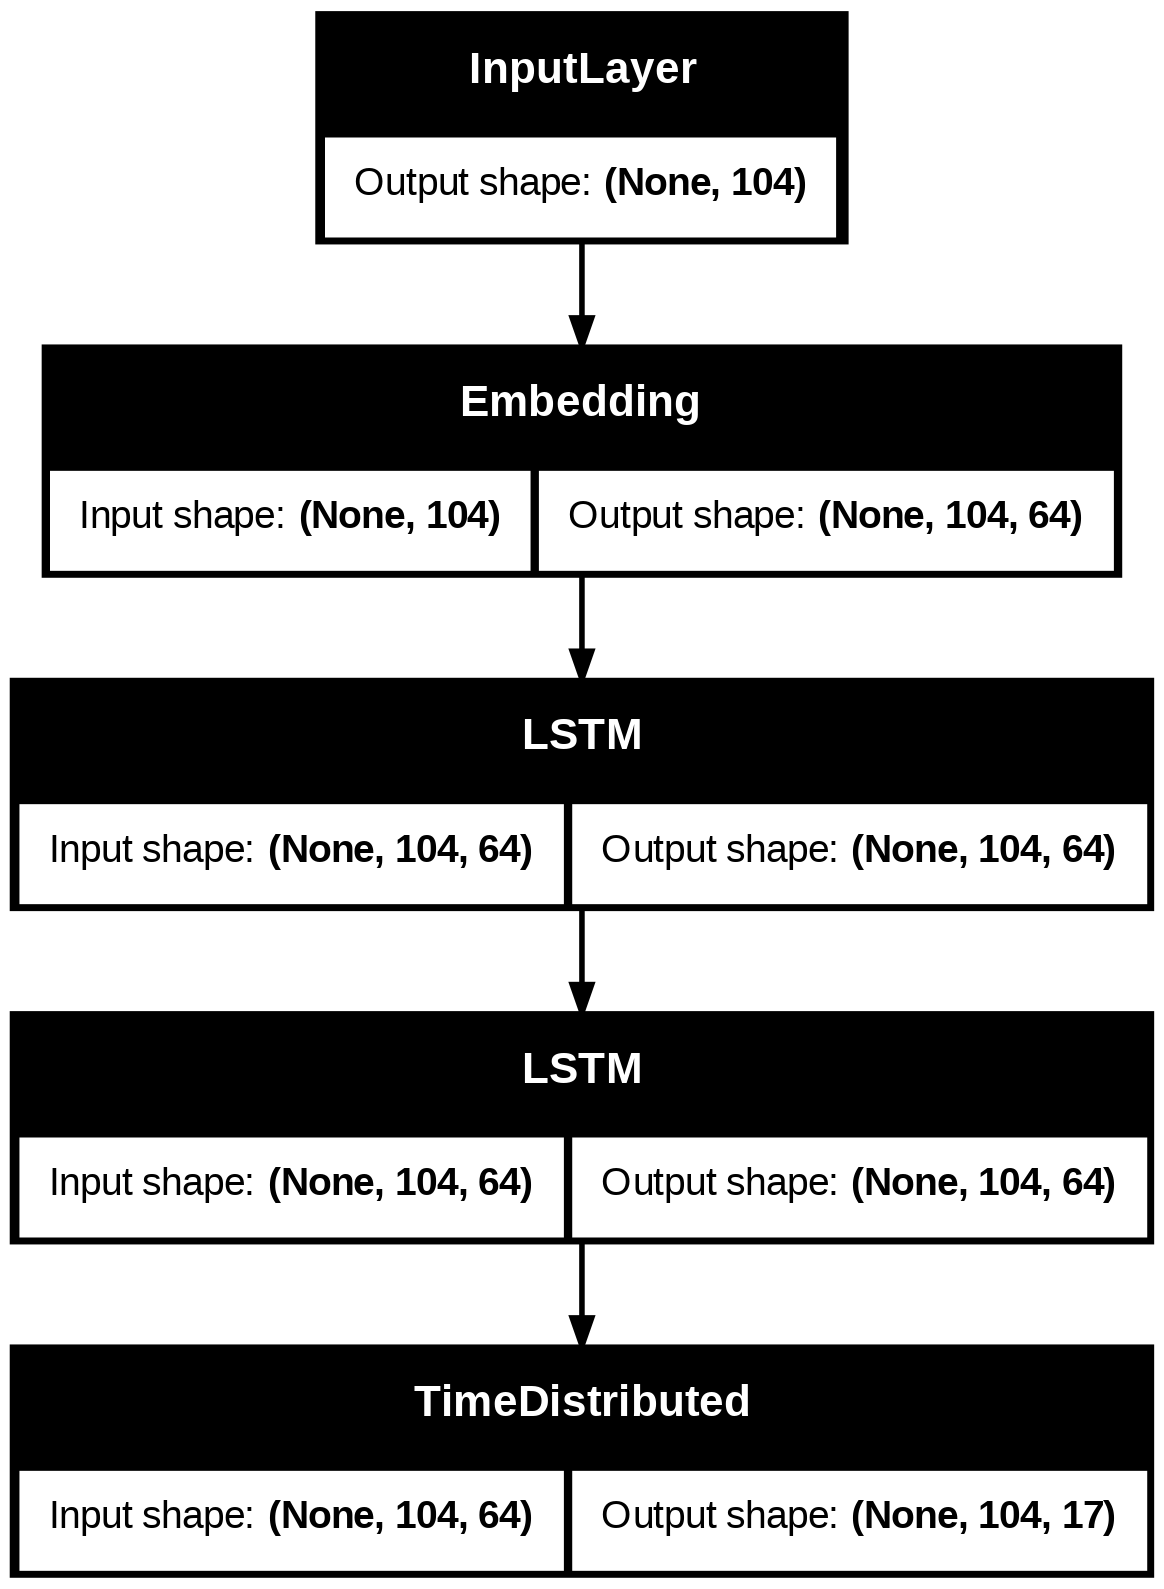

In [23]:
plot_model(model,show_shapes=True)


In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [25]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_model/best_ner_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [26]:
model.fit(x=train_statement,y=train_tag,batch_size=32,epochs=30,validation_data=(test_statement,test_tag),callbacks=callbacks)

Epoch 1/30
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9595 - loss: 0.3541
Epoch 1: val_accuracy improved from None to 0.97672, saving model to saved_model/best_ner_model.keras

Epoch 1: finished saving model to saved_model/best_ner_model.keras
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 99s 54ms/step - accuracy: 0.9676 - loss: 0.1899 - val_accuracy: 0.9767 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 2/30
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9713 - loss: 0.2130
Epoch 2: val_accuracy did not improve from 0.97672
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9647 - loss: 0.3819 - val_accuracy: 0.9707 - val_loss: 0.3790 - learning_rate: 0.0010
Epoch 3/30
1347/1349 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9490 - loss: 0.6998
Epoch 3: val_accuracy did not improve from 0.97672
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.9584 - loss: 0.5456 - val_accuracy: 0.9710 - val_loss: 0.3115 - learning_rate: 0.0010
Epoch 4/30
1349/1349 ━━━━━

In [27]:
loss, accuracy= model.evaluate(test_statement,test_tag)
print(f"Loss: {loss*100}")
print(f"Accuracy: {accuracy*100}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9767 - loss: 0.0759
Loss: 7.590240240097046
Accuracy: 97.67192602157593


In [28]:
model.save("ner_model.keras")

In [42]:
def predict(sentence):
    words = sentence.split()
    sentence = [word2id.get(word, word2id['UNK']) for word in words]
    sentence = pad_sequences([sentence], maxlen=max_len_statement, padding='post', value=word2id['The'])
    prediction = model.predict(sentence)
    prediction = np.argmax(prediction, axis=-1)
    prediction = [id2tag[i] for i in prediction[0]] # Fix: Access the first (and only) row of prediction
    return list(zip(words, prediction))

In [46]:


predict("Ali live in karachi")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


[('Ali', 'O'), ('live', 'O'), ('in', 'O'), ('karachi', 'B-tim')]